**Fake news detection**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
import re
import string

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import io
Fake_Data =pd.read_csv('/content/drive/MyDrive/ML DataSet/Fake.csv' )

Fake_Data.head(10)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"


In [ ]:
import io
Ture_Data =pd.read_csv('/content/drive/MyDrive/ML DataSet/True.csv' )

Ture_Data.head(10)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


In [ ]:
Fake_Data["class"] = 0
Ture_Data["class"] = 1

In [ ]:
Ture_Data.head(10)

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017",1
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017",1
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017",1
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017",1
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017",1


In [ ]:
Fake_Data.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [ ]:
fd = Fake_Data.drop(["title", "subject","date"], axis = 1)
td = Ture_Data.drop(["title", "subject","date"], axis = 1)

In [ ]:
fd.head(10)

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
5,The number of cases of cops brutalizing and ki...,0
6,Donald Trump spent a good portion of his day a...,0
7,In the wake of yet another court decision that...,0
8,Many people have raised the alarm regarding th...,0
9,Just when you might have thought we d get a br...,0


In [ ]:
td.head(10)

,text,class
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1
5,"WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",1
6,"WEST PALM BEACH, Fla (Reuters) - President Don...",1
7,The following statements were posted to the ve...,1
8,The following statements were posted to the ve...,1
9,WASHINGTON (Reuters) - Alabama Secretary of St...,1


In [ ]:
Merged_data = pd.concat([fd, td], axis =0 )

In [ ]:
Data = Merged_data.sample(frac = 1)

In [ ]:
Data.head(10)

,text,class
3374,It s no secret that there is no love lost betw...,0
3425,Donald Trump thought he could bully the Depart...,0
16809,BANGKOK (Reuters) - Drums and a band played as...,1
15022,"BHUBANESWAR, India (Reuters) - At least 16 peo...",1
419,WASHINGTON (Reuters) - The three top Democrats...,1
15530,Mexicans have been given a green light by Obam...,0
20785,MANILA (Reuters) - Philippine President Rodrig...,1
6700,NEW YORK/WASHINGTON (Reuters) - President-elec...,1
8947,A Florida two-year-old is in critical conditio...,0
21680,How many American taxpayer dollars have alread...,0


In [ ]:
def Preprocessing(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [ ]:
Data["text"] = Data["text"].apply(Preprocessing)

In [ ]:
Data.head(10)

,text,class
3374,it s no secret that there is no love lost betw...,0
3425,donald trump thought he could bully the depart...,0
16809,bangkok reuters drums and a band played as...,1
15022,bhubaneswar india reuters at least peopl...,1
419,washington reuters the three top democrats...,1
15530,mexicans have been given a green light by obam...,0
20785,manila reuters philippine president rodrig...,1
6700,new york washington reuters president elec...,1
8947,a florida two year old is in critical conditio...,0
21680,how many american taxpayer dollars have alread...,0


In [ ]:
x = Data["text"]
y = Data["class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

Vec = TfidfVectorizer()
Vec_train = Vec.fit_transform(x_train)
Vec_test = Vec.transform(x_test)

In [ ]:
type(Vec_train)
print(Vec_train)

  (0, 92289)	0.03250371473238871
  (0, 72388)	0.016783183296369804
  (0, 5586)	0.22212039472429188
  (0, 77946)	0.049027517468581104
  (0, 86986)	0.12285955734895983
  (0, 85828)	0.28027465315670885
  (0, 72848)	0.07463249762378894
  (0, 40392)	0.10956982138972468
  (0, 63168)	0.025380246806169807
  (0, 25776)	0.04849273292164116
  (0, 36496)	0.03375044681118532
  (0, 63612)	0.036377359077330376
  (0, 93642)	0.01246842076844513
  (0, 30791)	0.06874764834793794
  (0, 96498)	0.018827578645705376
  (0, 17455)	0.04937877765816866
  (0, 81674)	0.021021797170338686
  (0, 76494)	0.032083971556404564
  (0, 47254)	0.35873925065292167
  (0, 7567)	0.03186672521467116
  (0, 58798)	0.01403681915071806
  (0, 48296)	0.02925771610285555
  (0, 3261)	0.09394058518218783
  (0, 61321)	0.022885479861897748
  (0, 63446)	0.023233947591407515
  :	:
  (35916, 67315)	0.059451844623785
  (35916, 77571)	0.06259315402073151
  (35916, 58826)	0.2664671982723704
  (35916, 23195)	0.23476950731696739
  (35916, 46454)	0

Logistic Regression.

In [ ]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(Vec_train,y_train)

LogisticRegression()

In [ ]:
pred_lr=LR.predict(Vec_test)
LR.score(Vec_test, y_test)

0.9870824053452116

In [ ]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4728
           1       0.98      0.99      0.99      4252

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



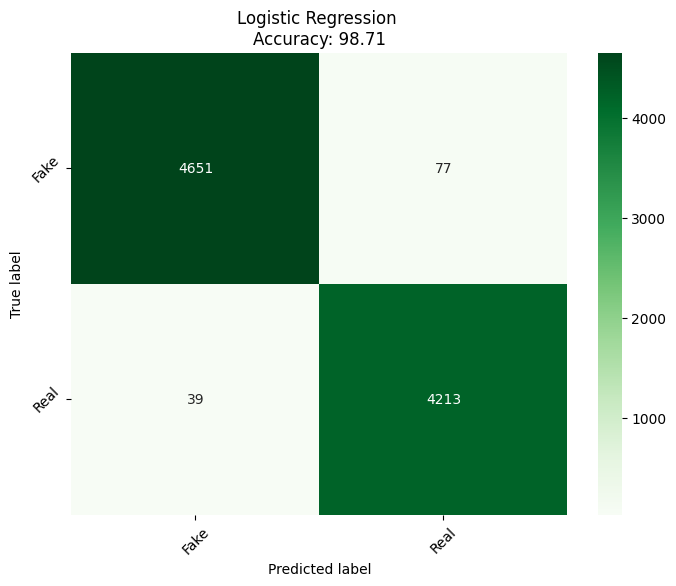

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test,pred_lr)

class_names = ['Fake', 'Real']
# Transform to df for easier plotting
cm_df = pd.DataFrame(cm,
                     index = class_names,
                     columns = class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True,cmap="Greens", fmt='g')
plt.title('Logistic Regression \nAccuracy: {0:.2f}'.format(accuracy_score(y_test, pred_lr)*100))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(Vec_train, y_train)

DecisionTreeClassifier()

In [ ]:
pred_dt = DT.predict(Vec_test)
DT.score(Vec_test, y_test)

0.9964365256124722

In [ ]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4724
           1       1.00      0.99      1.00      4256

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



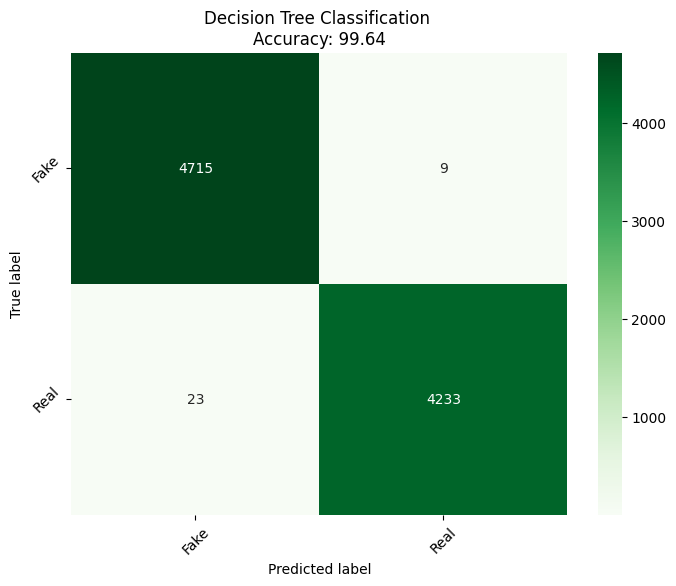

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test,pred_dt)

class_names = ['Fake', 'Real']
# Transform to df for easier plotting
cm_df = pd.DataFrame(cm,
                     index = class_names,
                     columns = class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True,cmap="Greens", fmt='g')
plt.title('Decision Tree Classification \nAccuracy: {0:.2f}'.format(accuracy_score(y_test, pred_dt)*100))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(Vec_train, y_train)

MultinomialNB()

In [ ]:
pred_NB = NB.predict(Vec_test)
NB.score(Vec_test, y_test)


0.9365256124721604

In [ ]:
print(classification_report(y_test, pred_NB))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4724
           1       0.94      0.93      0.93      4256

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



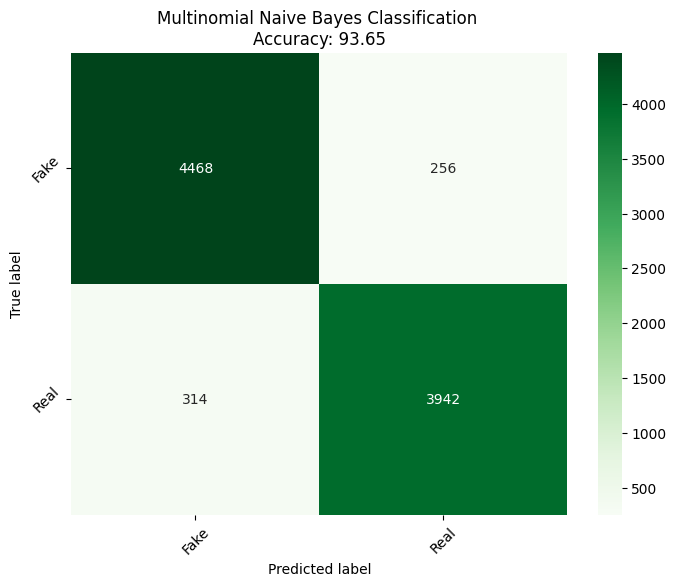

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test,pred_NB)

class_names = ['Fake', 'Real']
# Transform to df for easier plotting
cm_df = pd.DataFrame(cm,
                     index = class_names,
                     columns = class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True,cmap="Greens", fmt='g')
plt.title('Multinomial Naive Bayes Classification \nAccuracy: {0:.2f}'.format(accuracy_score(y_test, pred_NB)*100))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

K-Nearest Neighbour

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(Vec_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_knn = KNN.predict(Vec_test)
KNN.score(Vec_test, y_test)

0.7017817371937639

In [ ]:
print(classification_report(y_test, pred_knn))

              precision    recall  f1-score   support

           0       0.64      0.98      0.77      4724
           1       0.94      0.40      0.56      4256

    accuracy                           0.70      8980
   macro avg       0.79      0.69      0.67      8980
weighted avg       0.78      0.70      0.67      8980



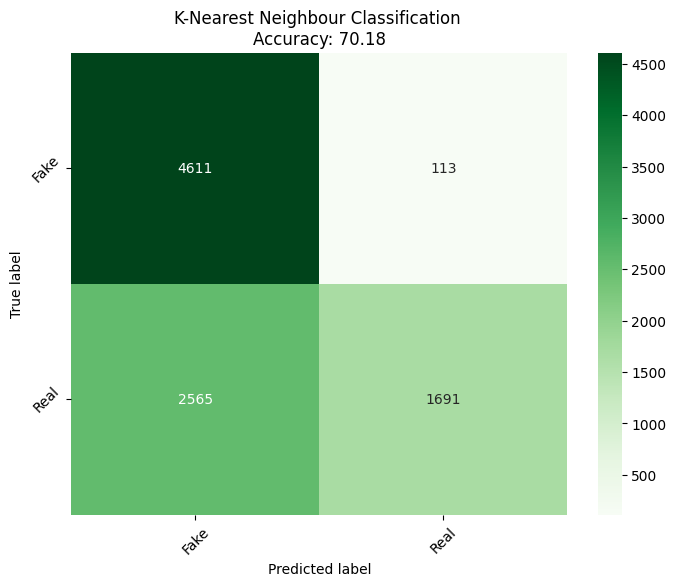

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test,pred_knn)

class_names = ['Fake', 'Real']
# Transform to df for easier plotting
cm_df = pd.DataFrame(cm,
                     index = class_names,
                     columns = class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True,cmap="Greens", fmt='g')
plt.title('K-Nearest Neighbour Classification \nAccuracy: {0:.2f}'.format(accuracy_score(y_test, pred_knn)*100))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()